Doodle-to-Real Image Translation using Pix2Pix

In [1]:

import subprocess
subprocess.run(['pip', 'install', 'gradio', 'scikit-image', '-q'], capture_output=True)

import os, sys, random, time, warnings, itertools
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import torchvision.utils as vutils
from torch.cuda.amp import GradScaler, autocast

from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

SEED = 39
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True
if torch.cuda.device_count() >= 2:
    print(f'Using {torch.cuda.device_count()} GPUs')
elif torch.cuda.is_available():
    print('Using single GPU')
else:
    print('Using CPU — training will be slow')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'   GPU {i}: {torch.cuda.get_device_name(i)}')
def denorm(t):
    """Denormalize tensor from [-1,1] to [0,1]."""
    return (t * 0.5 + 0.5).clamp(0, 1)

def to_numpy_img(t):
    return np.transpose(denorm(t.cpu()).numpy(), (1, 2, 0))

def weights_init(m):
    """DCGAN-style weight initialisation."""
    cls = m.__class__.__name__
    if 'Conv' in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in cls:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

print('\n setup complete.')

Using 2 GPUs
   GPU 0: Tesla T4
   GPU 1: Tesla T4

 setup complete.


### Hyperparameter

In [2]:
Q2_IMG_SIZE   = 256
Q2_BATCH      = 16
Q2_LR         = 0.0002
Q2_BETAS      = (0.5, 0.999)
Q2_LAMBDA_L1  = 100
Q2_EPOCHS     = 50
Q2_SAVE_EVERY = 10
Q2_SUBSET     = 2000

Q2_CUHK_PATH  = '/kaggle/input/datasets/arbazkhan971/cuhk-face-sketch-database-cufs'
Q2_ANIME_PATH = '/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair'
Q2_CKPT_DIR   = '/kaggle/working/q2_checkpoints'
os.makedirs(Q2_CKPT_DIR, exist_ok=True)
print('config ready.')

config ready.


### Data Loading

  Paired samples: 35538
Train: 2000 | Val: 100 | Batches/epoch: 125


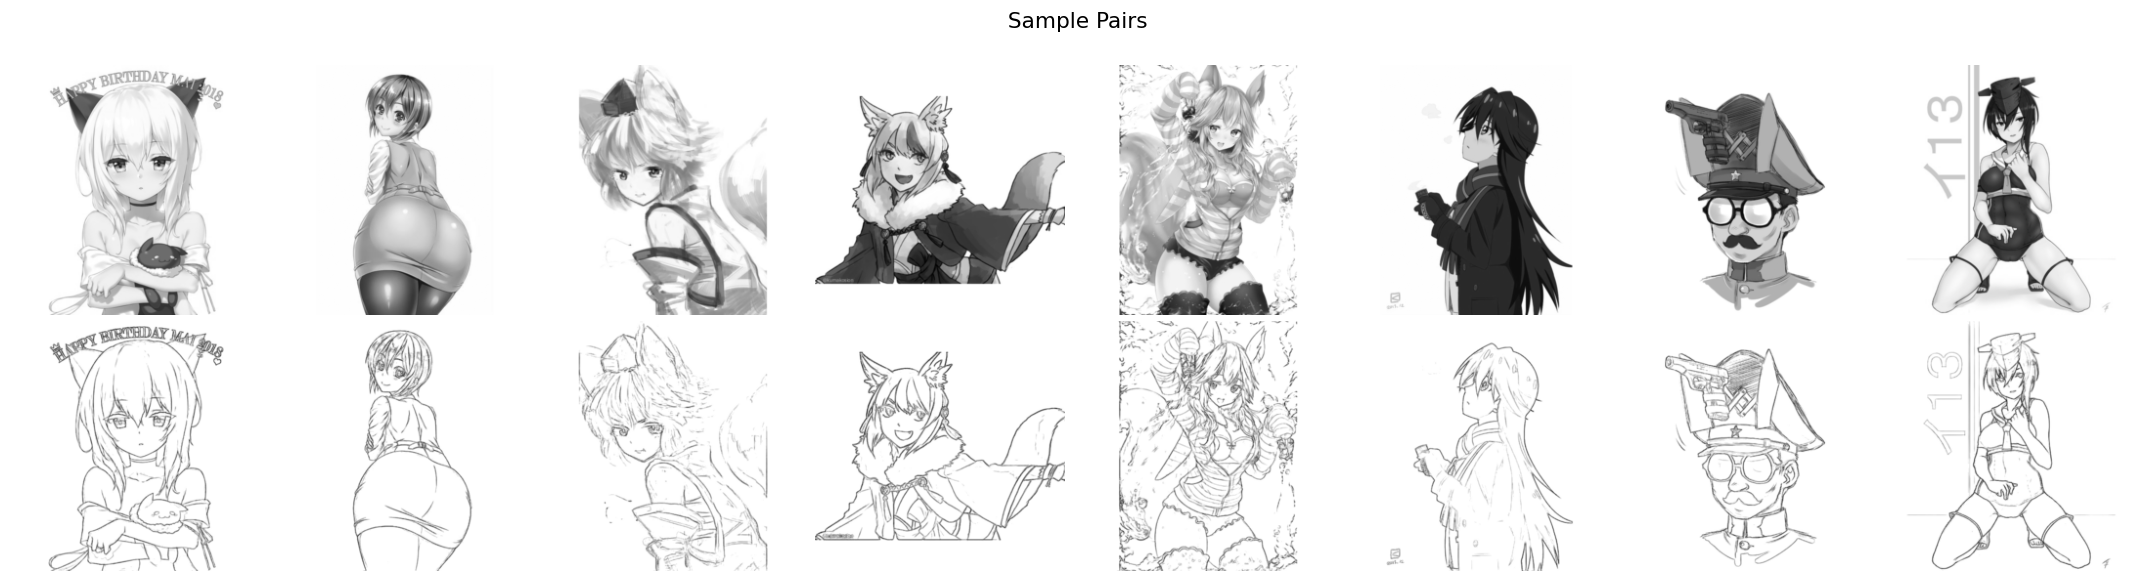

In [3]:
class PairedDataset(Dataset):
    """
    Handles two layouts:
      • side-by-side: single image with sketch on left, photo on right
      • two folders:  sketch/ and photo/ with matching filenames
    """
    EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

    def __init__(self, root, img_size=256, mode='sidebyside'):
        self.mode = mode; self.img_size = img_size; root = Path(root)
        if mode == 'sidebyside':
            self.paths = sorted([p for p in root.rglob('*') if p.suffix.lower() in self.EXTS])
        else:
            dirs = sorted([d for d in root.iterdir() if d.is_dir()])
            self.sketch_paths = sorted([p for p in dirs[0].rglob('*') if p.suffix.lower() in self.EXTS])
            self.photo_paths  = sorted([p for p in dirs[1].rglob('*') if p.suffix.lower() in self.EXTS])
            self.paths = list(zip(self.sketch_paths, self.photo_paths))

        self.tfm_rgb  = transforms.Compose([
            transforms.Resize((img_size, img_size), Image.BILINEAR),
            transforms.ToTensor(), transforms.Normalize([0.5]*3,[0.5]*3)])
        self.tfm_gray = transforms.Compose([
            transforms.Resize((img_size, img_size), Image.BILINEAR),
            transforms.Grayscale(3),
            transforms.ToTensor(), transforms.Normalize([0.5]*3,[0.5]*3)])
        print(f'  Paired samples: {len(self.paths)}')

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        if self.mode == 'sidebyside':
            img = Image.open(self.paths[idx]).convert('RGB')
            w, h = img.size; half = w // 2
            sketch = img.crop((0, 0, half, h))
            photo  = img.crop((half, 0, w, h))
        else:
            sketch = Image.open(self.paths[idx][0]).convert('RGB')
            photo  = Image.open(self.paths[idx][1]).convert('RGB')
        return self.tfm_gray(sketch), self.tfm_rgb(photo)


q2_ds = None
for path in [Q2_ANIME_PATH, Q2_CUHK_PATH]:
    if os.path.exists(path):
        try:
            q2_ds = PairedDataset(path, Q2_IMG_SIZE, 'sidebyside')
            if len(q2_ds) > 0: break
        except: pass

if q2_ds is None: raise RuntimeError(' No dataset found.')

idx = random.sample(range(len(q2_ds)), min(Q2_SUBSET, len(q2_ds)))
q2_train = Subset(q2_ds, idx)
q2_val   = Subset(q2_ds, idx[:100])
q2_train_loader = DataLoader(q2_train, Q2_BATCH, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
q2_val_loader   = DataLoader(q2_val,   Q2_BATCH, shuffle=False, num_workers=2)

print(f'Train: {len(q2_train)} | Val: {len(q2_val)} | Batches/epoch: {len(q2_train_loader)}')

sk, ph = next(iter(q2_train_loader))
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for j in range(8):
    axes[0,j].imshow(to_numpy_img(sk[j])); axes[0,j].axis('off')
    axes[1,j].imshow(to_numpy_img(ph[j])); axes[1,j].axis('off')
axes[0,0].set_ylabel('Sketch', fontsize=9); axes[1,0].set_ylabel('Photo', fontsize=9)
plt.suptitle(' Sample Pairs', fontsize=13)
plt.tight_layout(); plt.savefig('/kaggle/working/q2_samples.png', bbox_inches='tight'); plt.show()

### Pix2Pix Architecture

In [4]:
class UNetDown(nn.Module):
    def __init__(self, in_c, out_c, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if normalize: layers.append(nn.InstanceNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        if dropout: layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x): return self.model(x)


class UNetUp(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        layers = [nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
                  nn.InstanceNorm2d(out_c), nn.ReLU(True)]
        if dropout: layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x, skip): return torch.cat([self.model(x), skip], dim=1)


class UNetGenerator(nn.Module):
    """U-Net Generator: preserves spatial structure via skip connections."""
    def __init__(self, in_c=3, out_c=3):
        super().__init__()
        self.d1 = UNetDown(in_c, 64,  normalize=False)
        self.d2 = UNetDown(64,  128)
        self.d3 = UNetDown(128, 256)
        self.d4 = UNetDown(256, 512)
        self.d5 = UNetDown(512, 512)
        self.d6 = UNetDown(512, 512)
        self.d7 = UNetDown(512, 512)
        self.d8 = UNetDown(512, 512, normalize=False)  # bottleneck
        self.u1 = UNetUp(512,  512, dropout=0.5)
        self.u2 = UNetUp(1024, 512, dropout=0.5)
        self.u3 = UNetUp(1024, 512, dropout=0.5)
        self.u4 = UNetUp(1024, 512)
        self.u5 = UNetUp(1024, 256)
        self.u6 = UNetUp(512,  128)
        self.u7 = UNetUp(256,  64)
        self.final = nn.Sequential(nn.ConvTranspose2d(128, out_c, 4, 2, 1), nn.Tanh())

    def forward(self, x):
        d1=self.d1(x); d2=self.d2(d1); d3=self.d3(d2); d4=self.d4(d3)
        d5=self.d5(d4); d6=self.d6(d5); d7=self.d7(d6); d8=self.d8(d7)
        return self.final(self.u7(self.u6(self.u5(self.u4(self.u3(self.u2(self.u1(d8,d7),d6),d5),d4),d3),d2),d1))


class PatchGAN_D(nn.Module):
    """PatchGAN Discriminator: classifies 16×16 patches. Input: (sketch, photo) concatenated."""
    def __init__(self, in_c=6, ndf=64):
        super().__init__()
        def blk(ic, oc, norm=True):
            L = [nn.Conv2d(ic, oc, 4, 2, 1, bias=False)]
            if norm: L.append(nn.InstanceNorm2d(oc))
            L.append(nn.LeakyReLU(0.2, True)); return L
        self.model = nn.Sequential(
            *blk(in_c, ndf, norm=False), *blk(ndf, ndf*2),
            *blk(ndf*2, ndf*4), *blk(ndf*4, ndf*8),
            nn.ZeroPad2d((1,0,1,0)), nn.Conv2d(ndf*8, 1, 4, padding=1))
    def forward(self, sk, ph): return self.model(torch.cat([sk, ph], dim=1))


q2_netG = UNetGenerator().to(DEVICE)
q2_netD = PatchGAN_D().to(DEVICE)
if torch.cuda.device_count() > 1:
    q2_netG = nn.DataParallel(q2_netG)
    q2_netD = nn.DataParallel(q2_netD)

print(f'Generator  params: {sum(p.numel() for p in q2_netG.parameters())//1000}K')
print(f'Discriminator params: {sum(p.numel() for p in q2_netD.parameters())//1000}K')

Generator  params: 54404K
Discriminator params: 2766K


### Loss Functions & Optimizations

In [5]:
q2_crit_GAN = nn.BCEWithLogitsLoss()
q2_crit_L1  = nn.L1Loss()
q2_optG = optim.Adam(q2_netG.parameters(), lr=Q2_LR, betas=Q2_BETAS)
q2_optD = optim.Adam(q2_netD.parameters(), lr=Q2_LR, betas=Q2_BETAS)

def q2_lr_lambda(epoch):
    d = Q2_EPOCHS // 2
    return 1.0 if epoch < d else 1.0 - (epoch - d) / float(Q2_EPOCHS - d + 1)

q2_schedG = torch.optim.lr_scheduler.LambdaLR(q2_optG, q2_lr_lambda)
q2_schedD = torch.optim.lr_scheduler.LambdaLR(q2_optD, q2_lr_lambda)
q2_scaler = GradScaler()

q2_G_losses, q2_D_losses = [], []

print('Starting Pix2Pix training...')
print('='*65)
t0 = time.time()

for epoch in range(Q2_EPOCHS):
    q2_netG.train(); q2_netD.train()
    ep_G = ep_D = 0.0

    for sketch, real_photo in q2_train_loader:
        sketch     = sketch.to(DEVICE)
        real_photo = real_photo.to(DEVICE)
        b = sketch.size(0)
        with torch.no_grad():
            _s = q2_netD(sketch[:1], real_photo[:1])
            pshape = (b, *_s.shape[1:])
        real_t = torch.ones (pshape, device=DEVICE)
        fake_t = torch.zeros(pshape, device=DEVICE)
        q2_netD.zero_grad()
        with autocast():
            fake_photo = q2_netG(sketch)
            lossD = 0.5 * (q2_crit_GAN(q2_netD(sketch, real_photo), real_t) +
                           q2_crit_GAN(q2_netD(sketch, fake_photo.detach()), fake_t))
        q2_scaler.scale(lossD).backward()
        q2_scaler.step(q2_optD); q2_scaler.update()
        q2_netG.zero_grad()
        with autocast():
            lossG = (q2_crit_GAN(q2_netD(sketch, fake_photo), real_t) +
                     q2_crit_L1(fake_photo, real_photo) * Q2_LAMBDA_L1)
        q2_scaler.scale(lossG).backward()
        q2_scaler.step(q2_optG); q2_scaler.update()

        ep_G += lossG.item(); ep_D += lossD.item()

    q2_schedG.step(); q2_schedD.step()
    q2_G_losses.append(ep_G / len(q2_train_loader))
    q2_D_losses.append(ep_D / len(q2_train_loader))

    print(f'[Pix2Pix] Epoch {epoch+1:3d}/{Q2_EPOCHS}  '
          f'Loss_D: {q2_D_losses[-1]:.4f}  Loss_G: {q2_G_losses[-1]:.4f}  '
          f'({(time.time()-t0)/60:.1f} min)')

    if (epoch+1) % Q2_SAVE_EVERY == 0:
        torch.save(q2_netG.state_dict(), f'{Q2_CKPT_DIR}/p2p_G_ep{epoch+1}.pth')
        torch.save(q2_netD.state_dict(), f'{Q2_CKPT_DIR}/p2p_D_ep{epoch+1}.pth')

print(f' Pix2Pix done in {(time.time()-t0)/60:.1f} min')

Starting Pix2Pix training...
[Pix2Pix] Epoch   1/50  Loss_D: 0.3034  Loss_G: 23.7891  (1.6 min)
[Pix2Pix] Epoch   2/50  Loss_D: 0.4670  Loss_G: 9.4853  (3.2 min)
[Pix2Pix] Epoch   3/50  Loss_D: 0.4947  Loss_G: 8.2008  (4.8 min)
[Pix2Pix] Epoch   4/50  Loss_D: 0.3961  Loss_G: 8.0188  (6.4 min)
[Pix2Pix] Epoch   5/50  Loss_D: 0.2765  Loss_G: 8.6930  (8.0 min)
[Pix2Pix] Epoch   6/50  Loss_D: 0.5822  Loss_G: 6.2667  (9.6 min)
[Pix2Pix] Epoch   7/50  Loss_D: 0.3314  Loss_G: 7.1621  (11.2 min)
[Pix2Pix] Epoch   8/50  Loss_D: 0.0155  Loss_G: 9.5176  (12.9 min)
[Pix2Pix] Epoch   9/50  Loss_D: 0.4036  Loss_G: 7.4538  (14.5 min)
[Pix2Pix] Epoch  10/50  Loss_D: 0.3613  Loss_G: 6.8450  (16.2 min)
[Pix2Pix] Epoch  11/50  Loss_D: 0.6150  Loss_G: 5.6436  (17.8 min)
[Pix2Pix] Epoch  12/50  Loss_D: 0.0398  Loss_G: 8.4686  (19.4 min)
[Pix2Pix] Epoch  13/50  Loss_D: 0.0056  Loss_G: 9.7268  (21.0 min)
[Pix2Pix] Epoch  14/50  Loss_D: 0.0624  Loss_G: 9.9369  (22.7 min)
[Pix2Pix] Epoch  15/50  Loss_D: 0.5960

### Graphs 

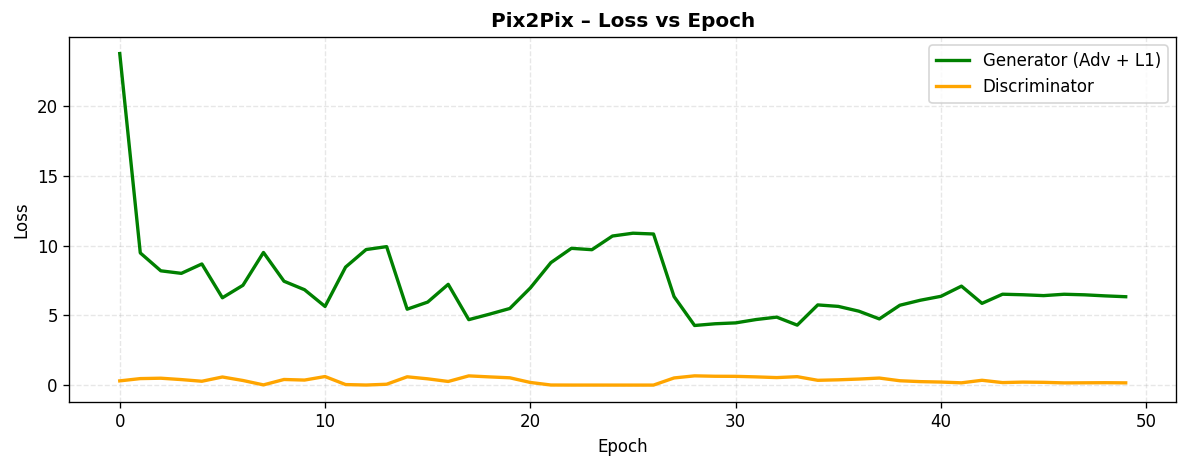

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(q2_G_losses, label='Generator (Adv + L1)', color='green', linewidth=2)
plt.plot(q2_D_losses, label='Discriminator',        color='orange', linewidth=2)
plt.title('Pix2Pix – Loss vs Epoch', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('/kaggle/working/q2_losses.png', bbox_inches='tight', dpi=150)
plt.show()

Quantitative Evaluation (Validation)
  SSIM : 0.9332 ± 0.0311
  PSNR : 26.50 ± 1.93 dB


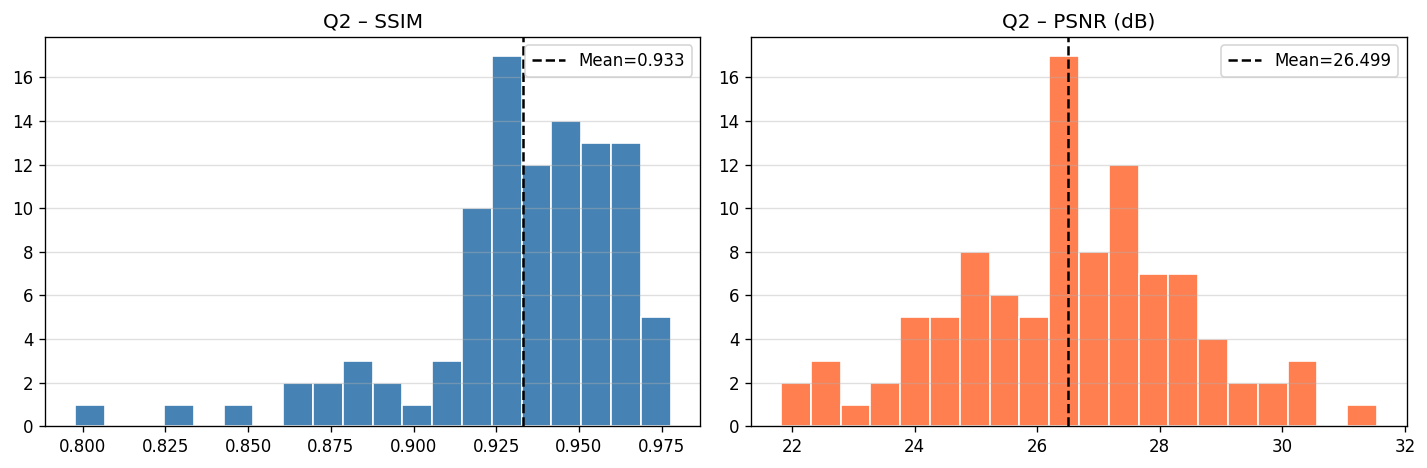

In [7]:
q2_ssim, q2_psnr = [], []
q2_netG.eval()
with torch.no_grad():
    for sk, ph in q2_val_loader:
        gen = q2_netG(sk.to(DEVICE)).cpu()
        for i in range(gen.size(0)):
            g = to_numpy_img(gen[i]); r = to_numpy_img(ph[i])
            q2_ssim.append(ssim_fn(r, g, data_range=1.0, channel_axis=2))
            q2_psnr.append(psnr_fn(r, g, data_range=1.0))

print('='*45)
print('Quantitative Evaluation (Validation)')
print(f'  SSIM : {np.mean(q2_ssim):.4f} ± {np.std(q2_ssim):.4f}')
print(f'  PSNR : {np.mean(q2_psnr):.2f} ± {np.std(q2_psnr):.2f} dB')
print('='*45)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title, color in zip(axes,
    [q2_ssim, q2_psnr], ['SSIM', 'PSNR (dB)'], ['steelblue', 'coral']):
    ax.hist(data, bins=20, color=color, edgecolor='white')
    ax.axvline(np.mean(data), color='black', linestyle='--',
               label=f'Mean={np.mean(data):.3f}')
    ax.set_title(f'Q2 – {title}'); ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('/kaggle/working/q2_metrics.png', bbox_inches='tight'); plt.show()

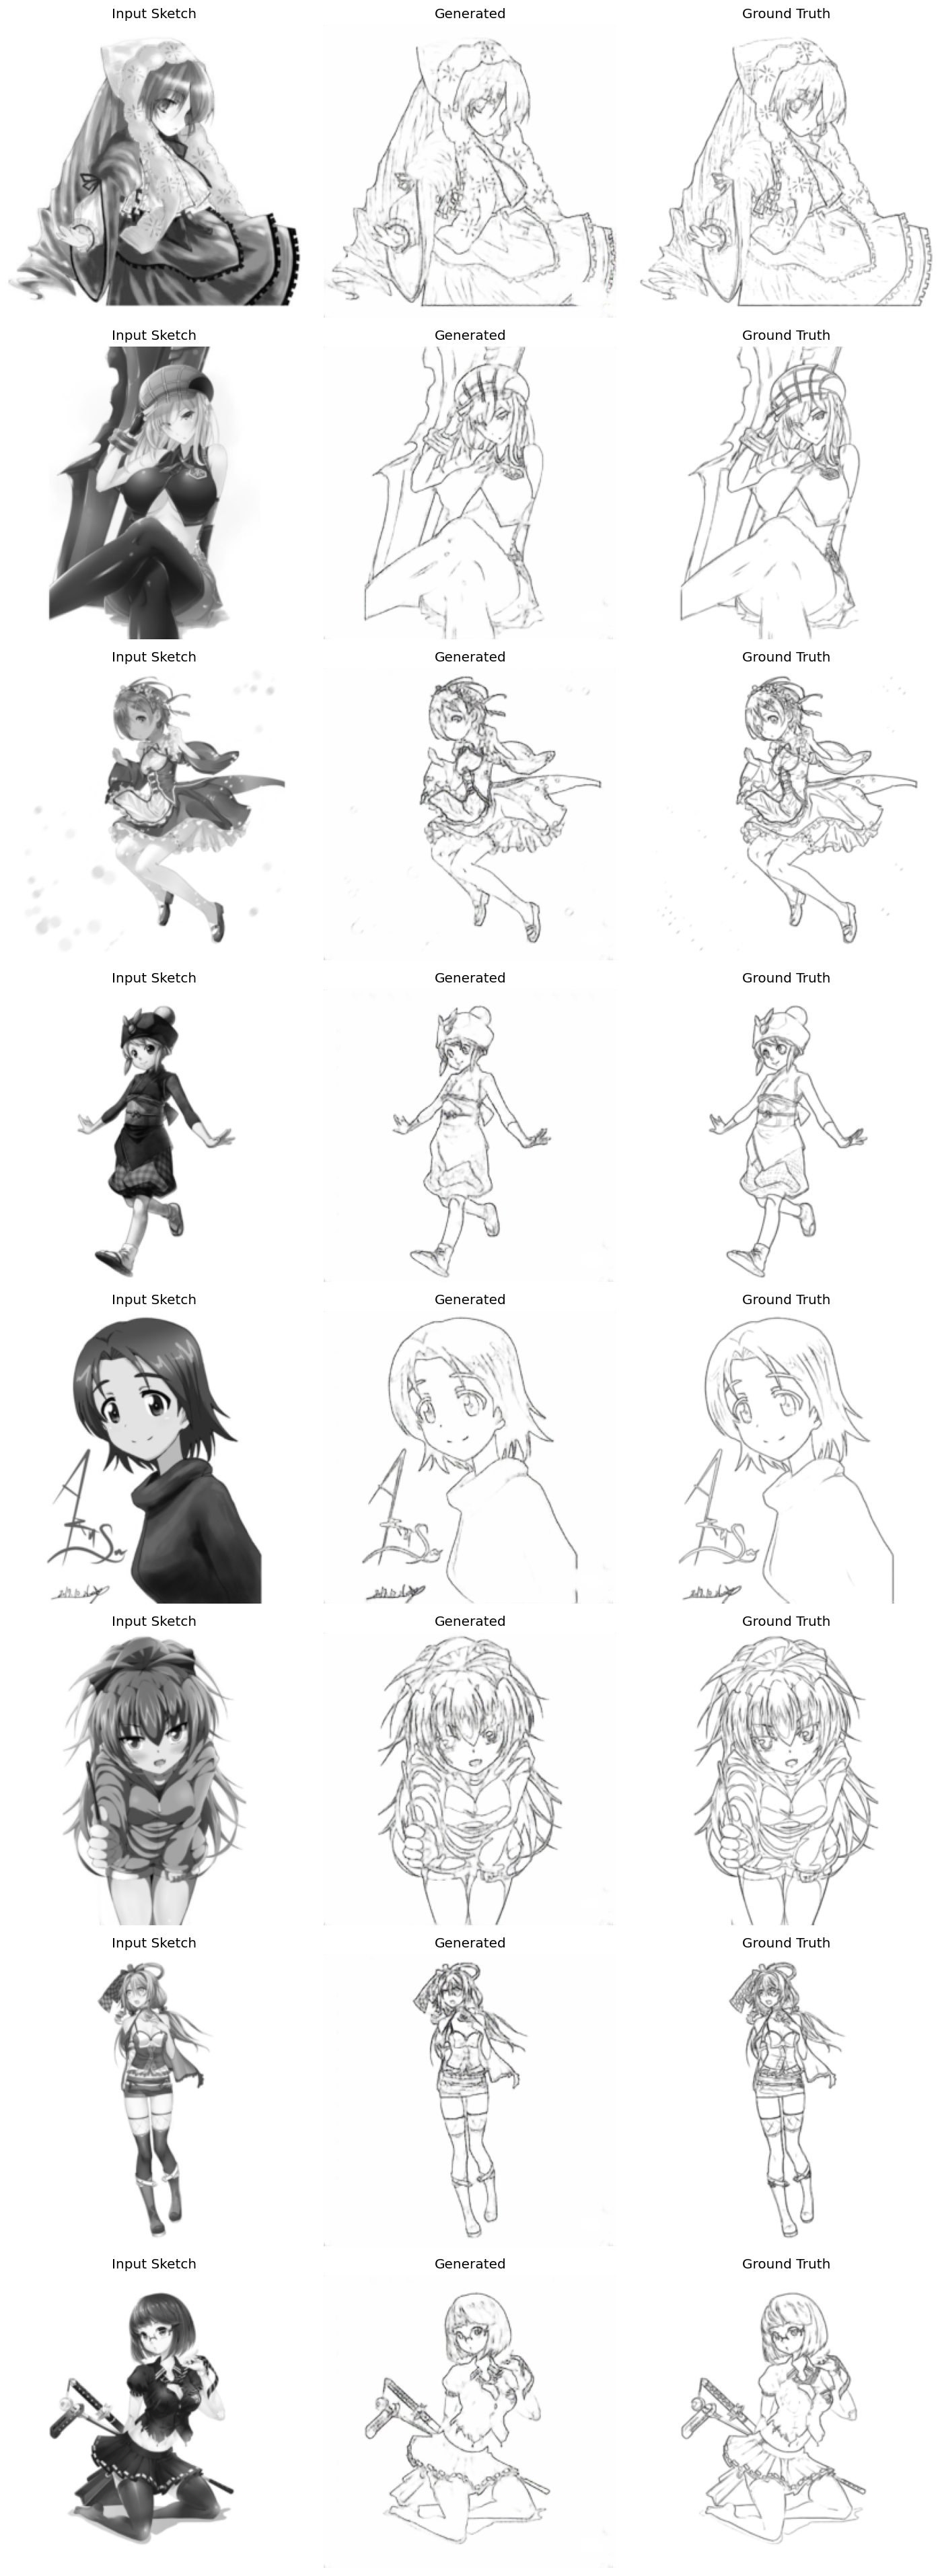

In [8]:
q2_netG.eval()
with torch.no_grad():
    sketch, real = next(iter(q2_val_loader))
    sketch = sketch.to(DEVICE)
    fake = q2_netG(sketch)
    n_samples = min(8, sketch.size(0))
    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))
    for i in range(n_samples):
        axes[i, 0].imshow(to_numpy_img(sketch[i]))
        axes[i, 0].set_title('Input Sketch')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(to_numpy_img(fake[i]))
        axes[i, 1].set_title('Generated')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(to_numpy_img(real[i]))
        axes[i, 2].set_title('Ground Truth')
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.savefig('/kaggle/working/q2_predictions.png', bbox_inches='tight')
    plt.show()

In [9]:
class ColorizationGenerator(UNetGenerator):
    def __init__(self):
        super().__init__(in_c=1, out_c=3) 

In [12]:
# Save model without DataParallel wrapper for Hugging Face
def save_model_for_huggingface():
    # Load your trained model
    model = UNetGenerator().to('cpu')
    
    # Load the checkpoint
    state_dict = torch.load(f'{Q2_CKPT_DIR}/p2p_G_ep50.pth', map_location='cpu')
    
    # Remove 'module.' prefix if present
    from collections import OrderedDict
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace('module.', '')
        new_state_dict[name] = v
    
    # Save the cleaned model
    model.load_state_dict(new_state_dict)
    torch.save(model.state_dict(), 'pix2pix_generator.pth')
    print("Model saved as 'pix2pix_generator.pth'")

save_model_for_huggingface()

Model saved as 'pix2pix_generator.pth'


In [11]:
import gradio as gr
from collections import OrderedDict
import os

def load_latest_model():
    """Load the latest checkpoint available"""
    # Find all generator checkpoints
    checkpoints = [f for f in os.listdir(Q2_CKPT_DIR) if f.startswith('p2p_G_ep') and f.endswith('.pth')]
    
    if not checkpoints:
        raise FileNotFoundError(f"No checkpoints found in {Q2_CKPT_DIR}")
    
    # Sort by epoch number and get the latest
    checkpoints.sort(key=lambda x: int(x.split('_ep')[1].split('.')[0]))
    latest_checkpoint = checkpoints[-1]
    
    print(f"Loading checkpoint: {latest_checkpoint}")
    
    # Load the trained generator
    model = UNetGenerator().to(DEVICE)
    
    # Load the state dict
    state_dict = torch.load(f'{Q2_CKPT_DIR}/{latest_checkpoint}', map_location=DEVICE)
    
    # Remove 'module.' prefix if it exists (for DataParallel)
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace('module.', '')  # remove 'module.' prefix
        new_state_dict[name] = v
    
    # Load the cleaned state dict
    model.load_state_dict(new_state_dict)
    model.eval()
    return model

# Load the model
model = load_latest_model()
print("Model loaded successfully!")

def generate_from_sketch(sketch_image):
    transform = transforms.Compose([
        transforms.Resize((Q2_IMG_SIZE, Q2_IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    
    # Convert to RGB if needed
    if sketch_image.mode != 'RGB':
        sketch_image = sketch_image.convert('RGB')
    
    # Preprocess
    sketch_tensor = transform(sketch_image).unsqueeze(0).to(DEVICE)
    
    # Generate
    with torch.no_grad():
        generated = model(sketch_tensor)
    
    # Convert to image (denormalize from [-1,1] to [0,1])
    generated_img = (generated[0].cpu() * 0.5 + 0.5).clamp(0, 1)
    generated_img = generated_img.permute(1, 2, 0).numpy()
    
    return (generated_img * 255).astype(np.uint8)

# Create Gradio interface
iface = gr.Interface(
    fn=generate_from_sketch,
    inputs=gr.Image(type="pil", label="Upload Sketch"),
    outputs=gr.Image(type="numpy", label="Generated Image"),
    title=" Sketch to Real Image Translation - Pix2Pix",
    description="Upload a sketch or edge image, and the model will generate a realistic image!",
    article="Built with PyTorch Pix2Pix",
    allow_flagging="never"
)

# Launch the app
iface.launch(share=True)

Loading checkpoint: p2p_G_ep50.pth
Model loaded successfully!
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://3d337a6051344923d5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
